In [1]:
import sys
from pathlib import Path

def find_repo_root_local(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "tools").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPO_ROOT = find_repo_root_local(Path.cwd())
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from scipy.signal import savgol_filter

STROKE_DATA_DIR = REPO_ROOT / "data" / "stroke" / "raw"
STROKE_RESULTS_DIR = REPO_ROOT / "results" / "stroke"

m_nifti_file = STROKE_DATA_DIR / "Processed_M/1/ep2d_fid_basic_bold_p2_18.nii.gz"
m_nifti_file_2 = STROKE_DATA_DIR / "Processed_M/2/ep2d_fid_basic_bold_p2_20.nii.gz"
m_nifti_file_4 = STROKE_DATA_DIR / "Processed_M/4/ep2d_fid_basic_bold_p2_25.nii.gz"
m_nifti_file_6 = STROKE_DATA_DIR / "Processed_M/6/ep2d_fid_basic_bold_p2_23.nii.gz"
m_nifti_file_7 = STROKE_DATA_DIR / "Processed_M/7/ep2d_fid_basic_bold_p2_31.nii.gz"

y_nifti_file = STROKE_DATA_DIR / "Processed_Y/1/ep2d_fid_basic_bold_p2_24.nii.gz"
y_nifti_file_2 = STROKE_DATA_DIR / "Processed_Y/2/ep2d_fid_basic_bold_p2_25.nii.gz"
y_nifti_file_4 = STROKE_DATA_DIR / "Processed_Y/4/ep2d_fid_basic_bold_p2_21.nii.gz"
y_nifti_file_6 = STROKE_DATA_DIR / "Processed_Y/6/ep2d_fid_basic_bold_p2_25.nii.gz"
y_nifti_file_7 = STROKE_DATA_DIR / "Processed_Y/7/ep2d_fid_basic_bold_p2_24.nii.gz"


In [2]:
from nilearn import datasets, image
img_m = nib.load(m_nifti_file)
img_y = nib.load(y_nifti_file)

data_m = img_m.get_fdata()
data_y = img_y.get_fdata()
mean_m = np.mean(data_m, axis=3)
mean_y = np.mean(data_y, axis=3)

yeo = datasets.fetch_atlas_yeo_2011()
atlas_yeo7 = nib.load(yeo.thick_7)    # 原始 2mm 模板

atlas_res = image.resample_img(
    atlas_yeo7,
    target_affine=img_m.affine,
    target_shape=img_m.shape[:3],
    interpolation='nearest'
)
yeo7_data_m = atlas_res.get_fdata().astype(int)  # 值域 1–7

atlas_res = image.resample_img(
    atlas_yeo7,
    target_affine=img_y.affine,
    target_shape=img_y.shape[:3],
    interpolation='nearest'
)
yeo7_data_y = atlas_res.get_fdata().astype(int)  # 值域 1–7

yeo7_labels = {
    1: 'Visual',
    2: 'Somatomotor',
    3: 'DorsalAttention',
    4: 'VentralAttention',
    5: 'Limbic',
    6: 'Frontoparietal',
    7: 'DefaultMode'
}


[get_dataset_dir] Dataset found in /Users/yxzuji/nilearn_data/yeo_2011


/var/folders/vh/pjl542w16gz9d4ftq8k0gxmh0000gn/T/ipykernel_55586/280487564.py:16: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_res = image.resample_img(
/var/folders/vh/pjl542w16gz9d4ftq8k0gxmh0000gn/T/ipykernel_55586/280487564.py:16: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  atlas_res = image.resample_img(
/var/folders/vh/pjl542w16gz9d4ftq8k0gxmh0000gn/T/ipykernel_55586/280487564.py:24: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_res = image.resample_img(
/var/folders/vh/pjl542w16gz9d4ftq8k0gxmh0000gn/T/ipykernel_55586/280487564.py:24: FutureWarning: From release 0.13.0 on

'\nm_network_mean = {}\ny_network_mean = {}\n\nfor net_id, net_name in yeo7_labels.items():\n    mask = (yeo7_data == net_id)             # bool 掩模\n    if mask.sum() == 0:\n        continue\n\n\n    # ① 如果用平均时序\n    m_network_mean[net_name] = mean_m[mask].mean()\n    y_network_mean[net_name] = mean_y[mask].mean()\n\n    # ② 如果想保留完整的空间结构 (64,64,34)，可这样做：\n    #   m_net_map = np.zeros_like(mean_m)\n    #   m_net_map[mask] = mean_m[mask]\n    #   nib.Nifti1Image(m_net_map, img_m.affine).to_filename(f\'m_net_{net_name}.nii.gz\')\n\n# 7. 输出检查\nprint("M 组各网络平均信号：", m_network_mean)\nprint("Y 组各网络平均信号：", y_network_mean)\n'

In [3]:
yeo7_data_m = np.squeeze(yeo7_data_m, axis=3)
yeo7_data_y = np.squeeze(yeo7_data_y, axis=3)


In [4]:
unique_vals = np.unique(yeo7_data_m)

m_roi = {}
y_roi = {}

for val in unique_vals:
    if val == 0:
        continue

    mask = (yeo7_data_m == val)            # 用真实编号做掩模
    if mask.sum() == 0:                   # 再次检查
        continue

    idxs = np.array(np.nonzero(mask)).T

    vals = mean_m[mask]

    points4d = np.concatenate([
        idxs,                              # (num_points, 3)
        vals[:, np.newaxis]               # (num_points, 1)
    ], axis=1)

    m_roi[int(val)] = points4d

for val in unique_vals:
    if val == 0:
        continue

    mask = (yeo7_data_y == val)            # 用真实编号做掩模
    if mask.sum() == 0:                   # 再次检查
        continue

    idxs = np.array(np.nonzero(mask)).T

    vals = mean_y[mask]

    points4d = np.concatenate([
        idxs,                              # (num_points, 3)
        vals[:, np.newaxis]               # (num_points, 1)
    ], axis=1)

    y_roi[int(val)] = points4d


/opt/anaconda3/envs/tpot/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting UMAP on combined data...


/opt/anaconda3/envs/tpot/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/tpot/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


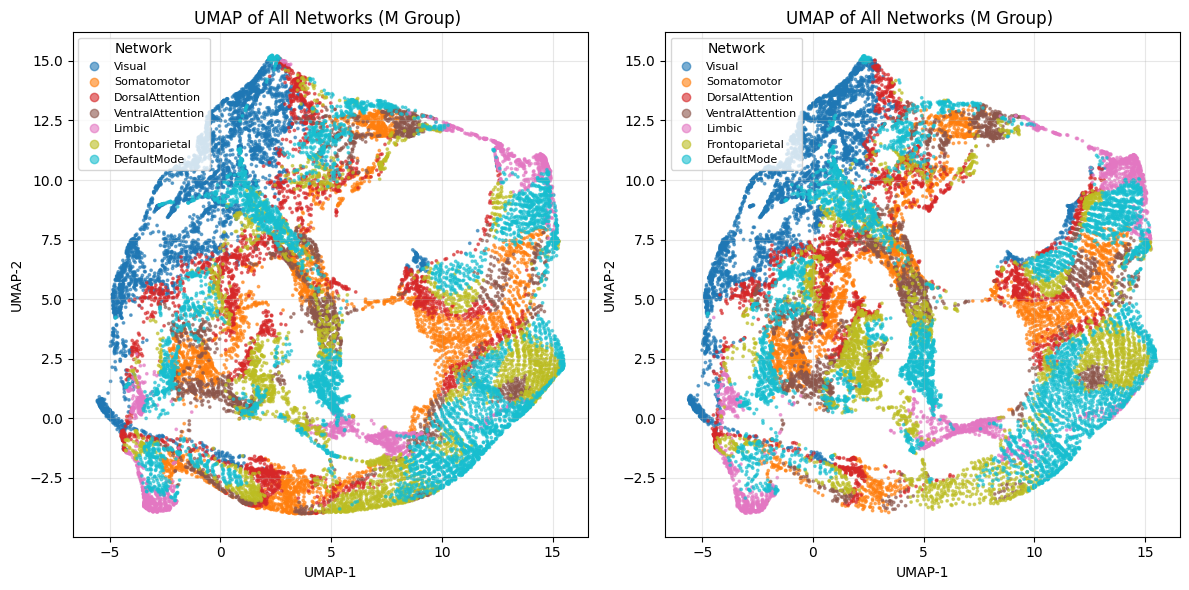

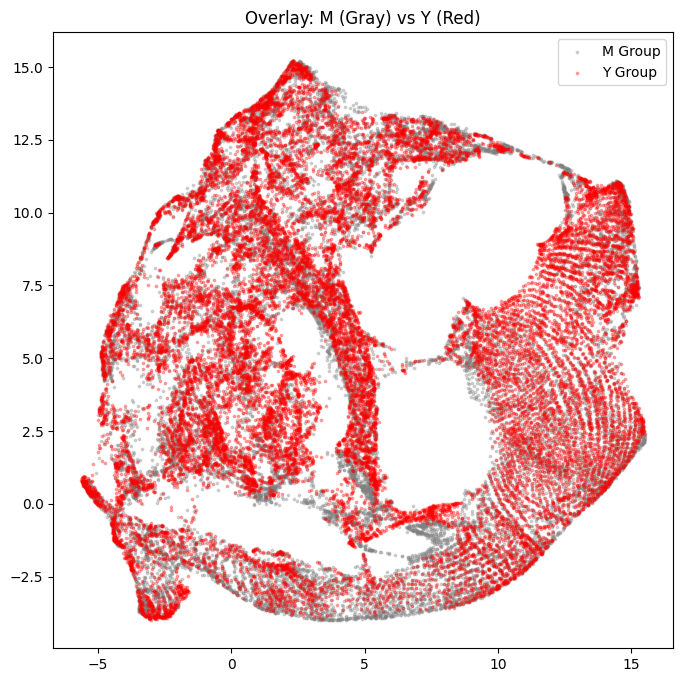

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from umap import UMAP

m_data_list = []
m_labels_list = []
y_data_list = []
y_labels_list = []

for val, points in m_roi.items():
    m_data_list.append(points)
    m_labels_list.extend([val] * len(points))

for val, points in y_roi.items():
    y_data_list.append(points)
    y_labels_list.extend([val] * len(points))

m_data = np.vstack(m_data_list)
y_data = np.vstack(y_data_list)
m_labels = np.array(m_labels_list)
y_labels = np.array(y_labels_list)

n_m_samples = m_data.shape[0]

combined_data = np.vstack([m_data, y_data])

scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_data)

print("Starting UMAP on combined data...")
reducer = UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
embedding_all = reducer.fit_transform(combined_scaled)

m_embedding = embedding_all[:n_m_samples]
y_embedding = embedding_all[n_m_samples:]

x_min, x_max = embedding_all[:, 0].min(), embedding_all[:, 0].max()
y_min, y_max = embedding_all[:, 1].min(), embedding_all[:, 1].max()
delta_x = (x_max - x_min) * 0.05
delta_y = (y_max - y_min) * 0.05
xlims = [x_min - delta_x, x_max + delta_x]
ylims = [y_min - delta_y, y_max + delta_y]

plt.figure(figsize=(12, 6))

ax1 = plt.subplot(1, 2, 1)
scatter1 = ax1.scatter(m_embedding[:, 0], m_embedding[:, 1],
                       c=m_labels, cmap='tab10', s=3, alpha=0.6)
ax1.set_title("UMAP of All Networks (M Group) ")
ax1.set_xlabel("UMAP-1")
ax1.set_ylabel("UMAP-2")
ax1.set_xlim(xlims) # 锁定坐标轴
ax1.set_ylim(ylims) # 锁定坐标轴
ax1.grid(True, alpha=0.3)

handles1, _ = scatter1.legend_elements()
labels_txt = [f'{yeo7_labels.get(i, f"Net {i}")}' for i in np.unique(m_labels)]
ax1.legend(handles1, labels_txt, title="Network", loc='best', fontsize=8)

ax2 = plt.subplot(1, 2, 2)
scatter2 = ax2.scatter(y_embedding[:, 0], y_embedding[:, 1],
                       c=y_labels, cmap='tab10', s=3, alpha=0.6)
ax2.set_title("UMAP of All Networks (M Group) ")
ax2.set_xlabel("UMAP-1")
ax2.set_ylabel("UMAP-2")
ax2.set_xlim(xlims) # 锁定坐标轴，非常重要！
ax2.set_ylim(ylims) # 锁定坐标轴
ax2.grid(True, alpha=0.3)

handles2, _ = scatter2.legend_elements()
ax2.legend(handles2, labels_txt, title="Network", loc='best', fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(m_embedding[:, 0], m_embedding[:, 1], c='gray', s=3, alpha=0.3, label='M Group')
plt.scatter(y_embedding[:, 0], y_embedding[:, 1], c='red', s=3, alpha=0.3, label='Y Group')
plt.title("Overlay: M (Gray) vs Y (Red)")
plt.legend()
plt.show()


In [6]:
m_region_points = []
y_region_points = []
region_lables = np.unique(m_labels)
for i in region_lables:
    region_points = []
    for label, point in zip(m_labels, m_embedding):
        if label==i:
            region_points.append(point)
    m_region_points.append(np.array(region_points))

region_lables = np.unique(y_labels)
for i in region_lables:
    region_points = []
    for label, point in zip(y_labels, y_embedding):
        if label==i:
            region_points.append(point)
    y_region_points.append(np.array(region_points))


In [7]:
import os
import warnings

import matplotlib
matplotlib.use('Agg')
import numpy as np
import ot
import pandas
import scipy as sp
import scipy.spatial
import tpot
from coot import dot, eta
from entropy import hyper_edge_entropy, hyper_graph_entropy, hypergraph_shannon_entropy, persist_entropy
from experiment_utils import align_2d as align
from experiment_utils import align_cycles, col_normalize, compute_coot_ot_gw_distances, cycle_entropy, get_affinities, reflect_points as reflect
from joblib import Parallel, delayed
from sklearn.manifold import MDS

import pd
import topfmain

warnings.filterwarnings("ignore")

def process_segment(segment, m_data, y_data, save_dir):

    log_prefix = f"[Seg {segment+1}]"

    if segment == 0:
        print(f"DEBUG: Process 0 writing to: {save_dir}")

    print(f'{log_prefix} >>> Started processing...', flush=True)

    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    m_embedding = m_data
    y_embedding = y_data

    fig1 = plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(m_embedding[:, 0], m_embedding[:, 1], s=5)
    plt.title("UMAP M-Embedding")
    plt.savefig(os.path.join(save_dir, f'whole{segment+1}_m_embedding.png'))
    plt.close(fig1)

    fig2 = plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 2)
    plt.scatter(y_embedding[:, 0], y_embedding[:, 1], s=5)
    plt.title("UMAP Y-Embedding")
    plt.savefig(os.path.join(save_dir, f'whole{segment+1}_y_embedding.png'))
    plt.close(fig2)

    N_m, N_y = m_embedding.shape[0], y_embedding.shape[0]
    rng = np.random.default_rng(seed=42)

    idx_m = rng.choice(N_m, size=600, replace=False)
    m_sampled = m_embedding[idx_m]

    idx_y = rng.choice(N_y, size=600, replace=False)
    y_sampled = y_embedding[idx_y]

    A = m_sampled
    B = y_sampled

    C_v0, C_v1 = get_affinities(A), get_affinities(B)

    print(f'{log_prefix} >>> Computing Persistent Homology...', flush=True)
    topf_all = [topfmain.topf(x, return_dict=True, complex_type='rips', fixed_num_features=[0, 30]) for x in [A, B]]
    y0 = topf_all[0][0]
    y1 = topf_all[1][0]

    df1, df2 = [pandas.DataFrame({"b": x[1]['birth_times'],
                                  "d": x[1]['death_times']}) for x in topf_all]
    p_spt, q_spt = df1.iloc[:, :2].values, df2.iloc[:, :2].values

    p, q = pd.augmented_weights(p_spt, q_spt)
    C_pd = pd.augmented_cost(p_spt, q_spt)

    print(f"{log_prefix} Running initial TPOT...", flush=True)
    alpha = 0.5
    beta = 1
    w0 = ot.unif(y0.shape[0])
    w1 = ot.unif(y1.shape[0])
    v0 = p
    v1 = q

    pi_s, pi_f, _, = tpot.TPOT(y0, y1, w0, w1, v0, v1,
                            C_v0, C_v1, C_pd,
                            beta=beta, alpha=alpha, print_iter=None, iter=100,
                            solver="sinkhorn",
                            eps_s=0.003, eps_f=0.01, numItermax=2500)

    print(f"{log_prefix} Calculating Geodesic paths...", flush=True)
    matching = np.array(np.where(ot.emd(w0, w1, pi_s.max()-pi_s) > 0)).T

    def local_geodesic_distances(a, b, t, indices):
        N = len(indices)
        M = np.zeros((N, N))
        for ii in range(N):
            Pi = np.array(a[indices[ii][0]])
            Qi = np.array(b[indices[ii][1]])
            for jj in range(ii+1, N):
                Pj = np.array(a[indices[jj][0]])
                Qj = np.array(b[indices[jj][1]])
                val = (1-t)* np.linalg.norm(Pi - Pj) + t*np.linalg.norm(Qi - Qj)
                M[ii][jj] = val
                M[jj][ii] = val
        return M

    def local_convex_point(a, b, t, indices):
        v = []
        for ii in range(len(indices)):
            Pi = np.array(a[indices[ii][0]])
            Qi = np.array(b[indices[ii][1]])
            v.append(Pi*(1-t) + Qi*t)
        return v

    num_frames = 51
    x1 = np.linspace(0, 1, num_frames, endpoint=True)

    matrices = [local_geodesic_distances(A, B, t, matching) for t in x1]
    convex_points = np.array([local_convex_point(A, B, t, matching) for t in x1])

    import warnings
    warnings.filterwarnings("ignore")

    model = MDS(n_components=2, dissimilarity='precomputed', random_state=2002)
    out = model.fit(matrices[0]).embedding_
    pos = align(out, convex_points[0])
    models_alligned = [pos]

    for ii in range(1, num_frames):
        print(f'{log_prefix} >>> Computing geodesic at frame{ii}/{num_frames}...', flush=True)
        true_pts = convex_points[ii]
        out = model.fit(matrices[ii]).embedding_
        pos = align(out, true_pts)
        rpos = reflect(pos)
        if np.linalg.norm(models_alligned[-1] - pos) > np.linalg.norm(models_alligned[-1] - rpos):
            pos = rpos
        models_alligned.append(pos)

    print(f'{log_prefix} >>> Calculating metrics along geodesic...')
    local_hge = []
    local_hee = []
    local_sym = []
    local_hse = []

    coot_values = []
    ot_values = []
    gw_values = []
    pe_values = []

    geodesic_pd_list = []
    yt_list = []
    point_score_abs_list = []

    para_alpha = 0.5

    M0_norm = col_normalize(y0)
    H0 = cycle_entropy(M0_norm)

    for i in range(1, num_frames):
        print(f'{log_prefix} >>> Processing metrics at frame{i}/{num_frames}...', flush=True)
        G = models_alligned[i-1]
        C_vt = get_affinities(G)

        topf_step = [topfmain.topf(G, return_dict=True, complex_type='rips', fixed_num_features=[0, 30])]
        yt = topf_step[0][0]
        dft = pandas.DataFrame({"b": topf_step[0][1]['birth_times'],
                                "d": topf_step[0][1]['death_times']})
        g_spt = dft.iloc[:, :2].values

        geodesic_pd_list.append(g_spt)
        yt_list.append(yt)

        p_step, g_step = pd.augmented_weights(p_spt, g_spt)
        C_pd_step = pd.augmented_cost(p_spt, g_spt)

        w0_step = ot.unif(y0.shape[0])
        wt_step = ot.unif(yt.shape[0])

        pi_s_step, pi_f_step, _, = tpot.TPOT(y0, yt, w0_step, wt_step, p_step, g_step,
                                          C_v0, C_vt, C_pd_step,
                                          beta=beta, alpha=alpha, print_iter=None, iter=100,
                                          solver="sinkhorn",
                                          eps_s=0.003, eps_f=0.01, numItermax=2500)

        cycle_matching = []
        pi_f_T = pi_f_step.T # 转置后遍历 yt 的特征
        for c_idx in range(len(pi_f_T)):
            sorted_indices = np.argsort(pi_f_T[c_idx])
            cycle_matching.append([c_idx, sorted_indices[-1]])

        Mt_aligned = align_cycles(y0, yt, cycle_matching)

        Mt_norm = col_normalize(Mt_aligned)
        Ht = cycle_entropy(Mt_norm)

        dH = Ht - H0
        point_score_abs = Mt_norm @ np.abs(dH)
        point_score_abs_list.append(point_score_abs)

        value = compute_coot_ot_gw_distances(y0, yt, C_v0, C_vt, C_pd_step, pi_s_step, pi_f_step, alpha, beta)

        coot_values.append(value[0]/beta)
        ot_values.append(value[1]/(1-alpha))
        gw_values.append(value[2]/alpha)

        pe_val = persist_entropy(g_spt)
        hge_val = hyper_graph_entropy(yt)
        hee_val = hyper_edge_entropy(yt)
        hse_val = hypergraph_shannon_entropy(yt)
        sym_val = para_alpha * hge_val + (1-para_alpha) * hee_val

        pe_values.append(pe_val)
        local_hge.append(hge_val)
        local_hee.append(hee_val)
        local_sym.append(sym_val)
        local_hse.append(hse_val)

    save_path = os.path.join(save_dir, f'segment_{segment+1}_full_results.npz')

    models_alligned_np = np.array(models_alligned)
    geodesic_pd_arr = np.array(geodesic_pd_list, dtype=object)
    yt_arr = np.array(yt_list, dtype=object)
    point_score_arr = np.array(point_score_abs_list, dtype=object)

    np.savez_compressed(
        save_path,
        hge_values=local_hge,
        hee_values=local_hee,
        sym_values=local_sym,
        hse_values=local_hse,
        pe_values=pe_values,
        coot_values=coot_values,
        ot_values=ot_values,
        gw_values=gw_values,
        models_alligned=models_alligned_np,
        geodesic_pd=geodesic_pd_arr,
        geodesic_yt=yt_arr,
        point_score_abs=point_score_arr,
        m_sampled=m_sampled,
        y_sampled=y_sampled
    )

    print(f'<<< Finished Segment {segment+1}, data saved to {save_path}')

    x_axis = np.arange(len(ot_values))
    t_vals = x_axis / (num_frames - 1)

    fig = plt.figure(figsize=(10, 8), constrained_layout=True)
    gs = fig.add_gridspec(2, 2)

    axA = fig.add_subplot(gs[0, :])
    axB = fig.add_subplot(gs[1, 0])
    axC = fig.add_subplot(gs[1, 1])

    axA.plot(t_vals, gw_values, label='Geometric')
    axA.plot(t_vals, ot_values, label='Topological')
    axA.plot(t_vals, coot_values, label='Incidence')

    axA.set_title('(a) Distortions')
    axA.set_xlabel(r'$t$')
    axA.set_ylabel('Value')
    axA.grid(True, alpha=0.3)
    axA.legend(loc='upper right', ncol=1, frameon=False)

    color_left = 'tab:blue'
    color_right = 'tab:red'

    axB.plot(t_vals, pe_values, color=color_left, label='PE')
    axB.set_xlabel(r'$t$')
    axB.set_ylabel('Persistence Entropy', color=color_left)
    axB.tick_params(axis='y', labelcolor=color_left)
    axB.grid(True, alpha=0.3)

    axB_r = axB.twinx()
    axB_r.plot(t_vals, local_sym, color=color_right, label='SHE')
    axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
    axB_r.tick_params(axis='y', labelcolor=color_right)

    she_mean = np.nanmean(local_sym)
    she_range = np.nanmax(local_sym) - np.nanmin(local_sym)
    pe_mean = np.nanmean(pe_values)
    pe_range = np.nanmax(pe_values) - np.nanmin(pe_values)

    if pe_range == 0: pe_range = 1.0
    if she_range == 0: she_range = 1.0

    axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
    axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

    axB.set_title('(b) Entropy-based event indicators')

    lines, labels = axB.get_legend_handles_labels()
    lines2, labels2 = axB_r.get_legend_handles_labels()
    axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

    axC.plot(t_vals, local_hee, label='HEE')
    axC.plot(t_vals, local_hge, label='HVE')

    axC.set_title('(c) Hypergraph Entropy')
    axC.set_xlabel(r'$t$')
    axC.set_ylabel('Entropy')
    axC.grid(True, alpha=0.3)
    axC.legend(loc='upper left', ncol=1, frameon=False)

    for ax in [axA, axB, axC]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ax == axB:
            axB_r.spines['top'].set_visible(False)

        ax.tick_params(axis='both', which='major', labelsize=9)

    fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)

    plt.savefig(os.path.join(save_dir, f'whole{segment+1}_curves.png'), bbox_inches='tight')
    plt.close(fig)

    if len(point_score_abs_list) > 0:
        final_score = point_score_abs_list[-1]

        plt.figure(figsize=(6, 5))

        sc = plt.scatter(y_sampled[:, 0], y_sampled[:, 1], c=final_score, s=8, cmap='coolwarm', alpha=0.95)
        plt.colorbar(sc, shrink=0.85, label=r'|ΔHE|')
        plt.title(f'Segment {segment+1} |ΔHE| (y0 vs y_final)')
        plt.xlabel('UMAP x')
        plt.ylabel('UMAP y')
        plt.grid(alpha=0.2)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'whole{segment+1}_deltaH_points.png'), dpi=300)
        plt.close()

    return save_path

if __name__ == "__main__":

    raw_save_dir = STROKE_RESULTS_DIR
    SAVE_DIR = os.path.abspath(raw_save_dir)

    try:
        if not os.path.exists(SAVE_DIR):
            os.makedirs(SAVE_DIR, exist_ok=True)
        print(f"Success: Directory created/verified at: {SAVE_DIR}")
    except Exception as e:
        print(f"Error creating directory: {e}")
        sys.exit(1)

    n_cores = 4
    print(f"Starting parallel processing on {n_cores} cores.")

    saved_files = Parallel(n_jobs=n_cores, verbose=10)(
        delayed(process_segment)(i, m_region_points[i], y_region_points[i], SAVE_DIR)
        for i in range(7)
    )

    print("All segments processed.")
    print("Saved files:", saved_files)


Success: Directory created/verified at: ../../results/stroke
Starting parallel processing on 4 cores.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Seg 2] >>> Started processing...
[Seg 4] >>> Started processing...
DEBUG: Process 0 writing to: ../../results/stroke
[Seg 1] >>> Started processing...
[Seg 3] >>> Started processing...
[Seg 2] >>> Computing Persistent Homology...
[Seg 3] >>> Computing Persistent Homology...
[Seg 4] >>> Computing Persistent Homology...
[Seg 1] >>> Computing Persistent Homology...
[Seg 2] Running initial TPOT...
is_converged, obj = 0.11291490778815783, obj_new = 0.11291490825323662
[Seg 2] Calculating Geodesic paths...
[Seg 1] Running initial TPOT...
is_converged, obj = 0.022661497718426862, obj_new = 0.022661498388121842
[Seg 1] Calculating Geodesic paths...
[Seg 2] >>> Computing geodesic at frame1/51...
[Seg 2] >>> Computing geodesic at frame2/51...
[Seg 2] >>> Computing geodesic at frame3/51...
[Seg 2] >>> Computing geodesic at frame4/51...
[Seg 2] >>> Computing geodesic at frame5/51...
[Seg 2] >>> Computing geodesic at frame6/51...
[Seg 2] >>> Computing geodesic at frame7/51...
[Seg 2] >>> Computing

[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed: 28.9min


[Seg 5] >>> Started processing...
[Seg 5] >>> Computing Persistent Homology...
is_converged, obj = 0.025293765099243012, obj_new = 0.02529376455417491
[Seg 3] >>> Processing metrics at frame31/51...
is_converged, obj = 0.03167424742228771, obj_new = 0.03167424655261094
[Seg 4] >>> Processing metrics at frame32/51...
is_converged, obj = 0.026799844635341546, obj_new = 0.02679984396241831
[Seg 3] >>> Processing metrics at frame32/51...
is_converged, obj = 0.029297064764549664, obj_new = 0.029297064061829102
[Seg 4] >>> Processing metrics at frame33/51...
is_converged, obj = 0.028217445667149288, obj_new = 0.028217444784003107
[Seg 3] >>> Processing metrics at frame33/51...
is_converged, obj = 0.027311619544219366, obj_new = 0.027311618979929942
[Seg 4] >>> Processing metrics at frame34/51...
is_converged, obj = 0.0302554827929641, obj_new = 0.030255481968705915
[Seg 3] >>> Processing metrics at frame34/51...
[Seg 5] Running initial TPOT...
is_converged, obj = 0.018649100713529952, obj_ne

...

[Parallel(n_jobs=4)]: Done   4 out of   7 | elapsed: 85.8min remaining: 64.3min


is_converged, obj = 0.03917391245156103, obj_new = 0.03917391307906572
[Seg 6] >>> Processing metrics at frame37/51...
is_converged, obj = 0.02633302898020137, obj_new = 0.026333028004401095
[Seg 1] >>> Processing metrics at frame42/51...
is_converged, obj = 0.01816670780652025, obj_new = 0.01816670681610364
[Seg 5] >>> Processing metrics at frame40/51...
is_converged, obj = 0.03867528808039434, obj_new = 0.03867528726443302
[Seg 6] >>> Processing metrics at frame38/51...
is_converged, obj = 0.023349568989091903, obj_new = 0.023349568460727346
[Seg 1] >>> Processing metrics at frame43/51...
is_converged, obj = 0.023216855705749273, obj_new = 0.02321685478981178
[Seg 1] >>> Processing metrics at frame44/51...
is_converged, obj = 0.01777074828080833, obj_new = 0.01777074766368351
[Seg 5] >>> Processing metrics at frame41/51...
is_converged, obj = 0.039044040098631626, obj_new = 0.03904403937351562
[Seg 6] >>> Processing metrics at frame39/51...
is_converged, obj = 0.023085017871450772, o

[Parallel(n_jobs=4)]: Done   5 out of   7 | elapsed: 90.8min remaining: 36.3min


is_converged, obj = 0.04060264400329359, obj_new = 0.040602644424813816
[Seg 6] >>> Processing metrics at frame44/51...
is_converged, obj = 0.02291876063413375, obj_new = 0.022918760689619698
[Seg 1] >>> Processing metrics at frame47/51...
is_converged, obj = 0.022998383816839253, obj_new = 0.022998383244753
[Seg 1] >>> Processing metrics at frame48/51...
is_converged, obj = 0.04136583541338502, obj_new = 0.04136583496794123
[Seg 6] >>> Processing metrics at frame45/51...
is_converged, obj = 0.02321494443469696, obj_new = 0.023214945238430394
[Seg 1] >>> Processing metrics at frame49/51...
is_converged, obj = 0.023061172570849733, obj_new = 0.023061171642833327
[Seg 1] >>> Processing metrics at frame50/51...
is_converged, obj = 0.04055353047915945, obj_new = 0.04055353072055683
[Seg 6] >>> Processing metrics at frame46/51...
is_converged, obj = 0.022734107909599885, obj_new = 0.022734108730470465
<<< Finished Segment 1, data saved to ../../results/stroke/segment_1_full_results.npz
is_c

[Parallel(n_jobs=4)]: Done   7 out of   7 | elapsed: 96.7min finished
